# Proyecto 3
#### Gabriela Mazariegos - 22513 
#### Giovanni Santos - 22523
#### Santiago Pereira - 22318
#### Brandon Reyes - 22992

Link repositorio: https://github.com/BrandonReyes0609/Proyecto3_MD.git

# ---------------------------------------------------
## Semana 1 - Preparación de Datos y Análisis Inicial
# ---------------------------------------------------

## A. Propuesta inicial del proyecto 
### 1. Planteamiento del problema

Este proyecto nace de la exigencia de explorar más a fondo el intrincado universo del comportamiento de los consumidores y la logística de entregas en el enérgico escenario del comercio electrónico en Brasil. En este escenario, Olist, una de las plataformas nos brinda información: más de 100,000 órdenes registradas desde 2016 hasta 2018. Estos números no son simplemente cifras, son un mosaico que muestra dinámicas vinculadas a productos, clientes, métodos de pago, localización geográfica, plazos de entrega y las valoraciones que los consumidores otorgan, transformándose en un inestimable testimonio de sus vivencias. En un contexto en el que la eficacia logística y la satisfacción del cliente se ven como el núcleo de la competitividad en el comercio electrónico, resulta esencial disponer de una estrategia de gestión logística eficaz.

En un contexto en el que la eficiencia logística y la satisfacción del cliente se ven como el núcleo de la competitividad en el comercio electrónico, resulta esencial disponer de herramientas de análisis predictivo que nos faciliten no solo prever conductas, sino también potenciar cada elección que realizamos.  Por lo tanto, nos sugerimos utilizar métodos de minería de datos y aprendizaje automático para explorar este amplio volumen de información, con el objetivo de responder a cuestiones como:  ¿Qué factores influyen en la calificación que da el cliente?, ¿Qué tan confiables son los tiempos de entrega estimados?, ¿Qué categorías de productos tienden a recibir mejores evaluaciones o a experimentar retrasos?

Este análisis se considera relevante no solo para fines académicos, sino también para su potencial  práctica dentro de la empresa, ya que los resultados obtenidos podrían contribuir directamente a la toma de decisiones operativas y estratégicas dentro de Olist. El reto principal radica en transformar esta gran cantidad de datos crudos en conocimiento útil que aporte valor tangible.

### 2. Metodología 
Para abordar el problema planteado, se diseñó una metodología que será desarrollada a lo largo de cinco semanas, cada una con entregables y objetivos claramente definidos. En la Semana 1, se enfocará en la preparación de los datos, lo cual implica su limpieza, transformación y análisis exploratorio. Esta fase es clave porque de la calidad del preprocesamiento dependerá el éxito de los modelos de machine learning que se aplicarán posteriormente.

La metodología general incluye los siguientes pasos:

  1. Carga y exploración inicial del dataset: Se analizarán los archivos provistos por Olist para identificar columnas relevantes, tipos de variables y presencia de datos nulos.

  2. Limpieza de datos: Se procederá a eliminar registros incompletos o irrelevantes, unificar formatos y corregir inconsistencias.

  3. Análisis exploratorio de datos (EDA): Se realizarán visualizaciones y resúmenes estadísticos para comprender mejor los patrones existentes.

  4. Transformación de variables: Se crearán nuevas columnas que representen mejor la información latente (por ejemplo, tiempos de entrega, año y mes de compra, codificación de categorías, etc.).

  5. Modelado predictivo (regresión y clasificación): En las siguientes semanas se entrenarán modelos de regresión (como Random Forest Regressor, Ridge, Lasso) y de clasificación (como Decision Trees, SVM, Naive Bayes), según el tipo de variable objetivo.

  6. Validación cruzada y redes neuronales: Se implementará validación k-fold y se probarán modelos de redes neuronales simples para evaluar mejoras en el rendimiento.

  7. Análisis comparativo final: Se documentarán los resultados de cada modelo y se generarán recomendaciones para Olist, priorizando aquellas que puedan tener impacto real en sus operaciones

### 3. Objetivos y Resultados esperados
El proyecto tiene como propósito central aplicar técnicas de análisis de datos y machine learning sobre el dataset proporcionado por Olist, con el fin de obtener información estratégica que contribuya a la mejora de sus procesos internos y la experiencia del cliente. Se definen los siguientes objetivos específicos:
 - Predecir el nivel de satisfacción del cliente utilizando modelos de clasificación, basándose en variables como categoría del producto, tiempo de entrega y ubicación del cliente.
 - Analizar los factores logísticos que influyen en los tiempos de entrega, tales como distancia entre vendedor y cliente, método de pago y categoría de producto.
 - Realizar un análisis estadístico detallado, que permita justificar las decisiones técnicas adoptadas durante el desarrollo del proyecto.





## B.  Reporte EDA

In [1]:
import pandas as pd


orders = pd.read_csv("csv/olist_orders_dataset.csv")
customers = pd.read_csv("csv/olist_customers_dataset.csv")
reviews = pd.read_csv("csv/olist_order_reviews_dataset.csv")
order_items = pd.read_csv("csv/olist_order_items_dataset.csv")
products = pd.read_csv("csv/olist_products_dataset.csv")
sellers = pd.read_csv("csv/olist_sellers_dataset.csv")
payments = pd.read_csv("csv/olist_order_payments_dataset.csv")
geolocation = pd.read_csv("csv/olist_geolocation_dataset.csv")
categories = pd.read_csv("csv/product_category_name_translation.csv")

### 1. Calidad del análisis exploratorio


In [2]:
orders.info()
orders.isna().sum()
orders.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


### 2. Visualizaciones efectivas

Para facilitar la comprensión de los patrones de comportamiento presentes en el dataset, se generaron diversas visualizaciones que permiten observar tendencias generales y relaciones entre variables. Las gráficas fueron elaboradas utilizando matplotlib y seaborn.

2.1 Distribución de evaluaciones de los clientes

/var/folders/c4/s77cmlbj0kvc81_ktl3p92vm0000gn/T/ipykernel_35044/2249801283.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="review_score", data=reviews, palette="viridis")


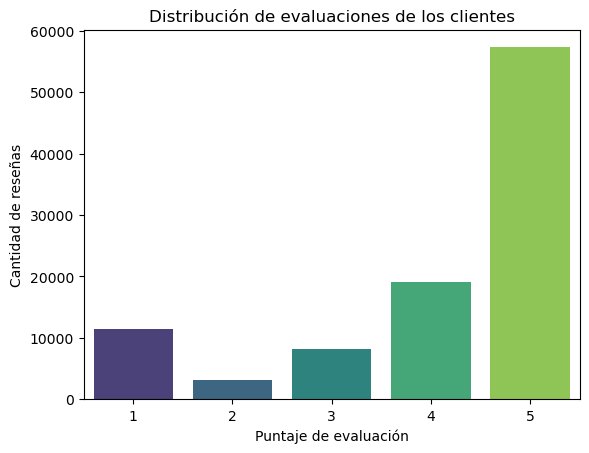

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="review_score", data=reviews, palette="viridis")
plt.title("Distribución de evaluaciones de los clientes")
plt.xlabel("Puntaje de evaluación")
plt.ylabel("Cantidad de reseñas")
plt.show()

La mayoría de los clientes otorgan 5 estrellas, lo que indica una tendencia positiva en las evaluaciones. También se observa un número significativo de evaluaciones con 1 estrella. Los puntajes intermedios (2 y 3) son menos comunes, lo que sugiere que los usuarios solo califican si están muy satisfechos o insatisfechos.

 2.2 Tiempo de entrega real

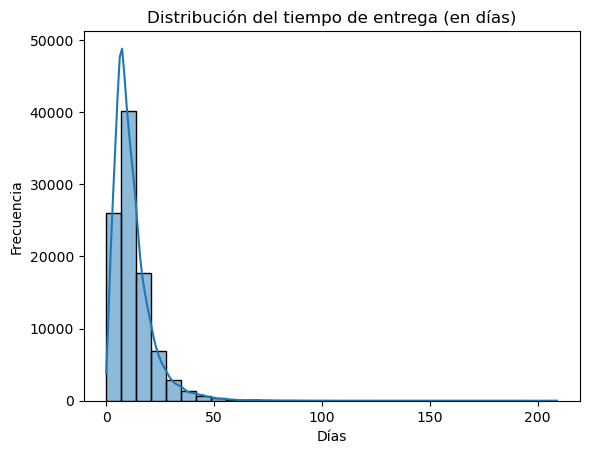

In [4]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["delivery_time_days"] = (orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]).dt.days

sns.histplot(data=orders, x="delivery_time_days", bins=30, kde=True)
plt.title("Distribución del tiempo de entrega (en días)")
plt.xlabel("Días")
plt.ylabel("Frecuencia")
plt.show()

El tiempo promedio de entrega es de aproximadamente 10 días. La mayoría de los pedidos se entregan entre 0 y 20 días, pero hay varios casos atípicos con entregas superiores a 100 días. La distribución está sesgada a la derecha.


2.3 Top 10 ciudades con más compras

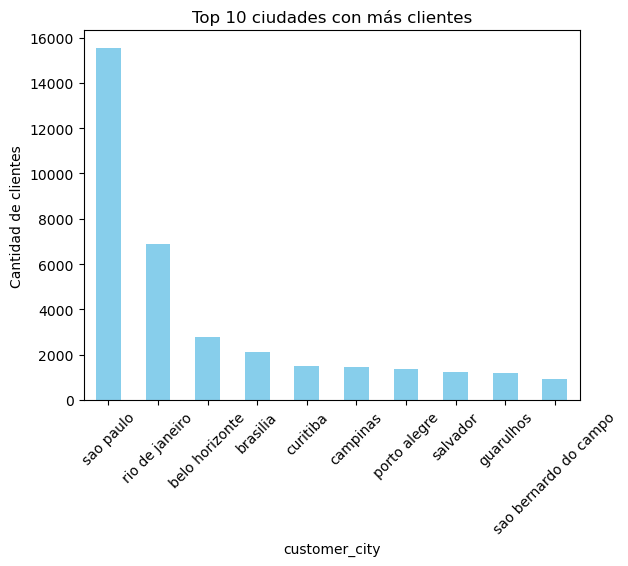

In [5]:
top_cities = customers["customer_city"].value_counts().head(10)
top_cities.plot(kind='bar', color='skyblue')
plt.title("Top 10 ciudades con más clientes")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=45)
plt.show()

São Paulo lidera con diferencia la cantidad de clientes, seguida por Rio de Janeiro y Belo Horizonte. Estas ciudades representan la mayor parte de la actividad comercial del dataset, lo que indica una concentración urbana en el uso de la plataforma.



### 3. Análisis estadístico

Se mostrará la media, desviación estándar, mínimo, máximo y percentiles de los días que tarda en entregarse un pedido. 
Es este caso es útil para entender el comportamiento general de la logística.


3.1 Estadísticas descriptivas del tiempo de entrega

In [6]:
orders[[
    "order_approved_at", 
    "order_delivered_carrier_date", 
    "order_delivered_customer_date", 
    "order_estimated_delivery_date"
]].dtypes


order_approved_at                        object
order_delivered_carrier_date             object
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date            object
dtype: object

El tiempo promedio de entrega fue de 12.09 días, con una mediana de 10 días. La mayoría de las entregas se realizaron entre 6 y 15 días. El valor máximo registrado fue de 209 días, lo que indica la presencia de valores extremos o atípicos.

3.2 Matriz de correlación entre variables numéricas

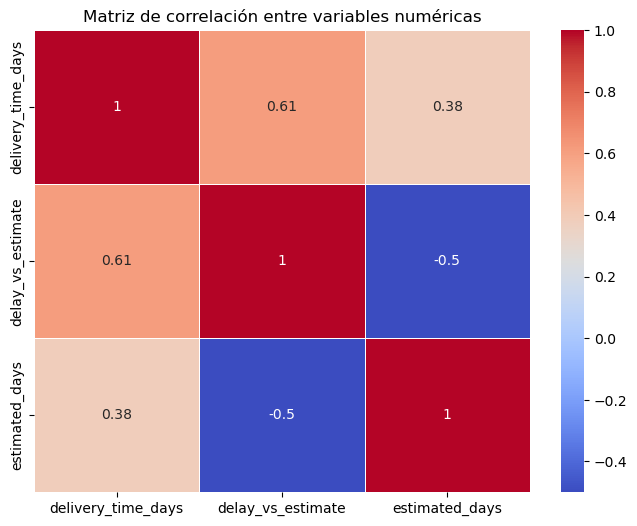

In [7]:
import pandas as pd

orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])

orders["delivery_time_days"] = (orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]).dt.days
orders["delay_vs_estimate"] = (orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]).dt.days
orders["estimated_days"] = (orders["order_estimated_delivery_date"] - orders["order_purchase_timestamp"]).dt.days

numeric_cols = orders[["delivery_time_days", "delay_vs_estimate", "estimated_days"]]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Matriz de correlación entre variables numéricas")
plt.show()



 - 'delivery_time_days' y 'delay_vs_estimate' tienen una correlación positiva de 0.61, lo que indica que mientras más se retrasa la entrega respecto al estimado, mayor es el tiempo total de entrega.

 - 'delay_vs_estimate' y 'estimated_days' tienen una correlación negativa de -0.50, lo que sugiere que cuando los tiempos estimados son más largos, el retraso tiende a ser menor.

 - 'delivery_time_days' y 'estimated_days' tienen una correlación moderada (0.38), indicando una relación débil pero positiva.

## C. Dataset preprocesado

 ### 1. Limpieza de datos

Antes de aplicar cualquier modelo predictivo, es necesario asegurar la calidad del conjunto de datos. Se realizó una limpieza básica para eliminar valores nulos relevantes, especialmente en fechas necesarias para el cálculo del tiempo de entrega, y se eliminaron registros con inconsistencias evidentes. También se filtraron aquellas filas donde no hay evidencia de que el pedido haya sido entregado, lo cual es crucial para calcular las métricas logísticas.


In [8]:
orders_clean = orders.copy()

orders_clean = orders_clean.dropna(subset=[
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
])

orders_clean.reset_index(drop=True, inplace=True)

orders_clean.isna().sum()


order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
delivery_time_days                0
delay_vs_estimate                 0
estimated_days                    0
dtype: int64

Se eliminaron registros con valores nulos en las columnas clave relacionadas a fechas: 
 - order_purchase_timestamp, 
 - order_delivered_customer_date
 - order_estimated_delivery_date. 

Esto garantizó que todas las observaciones incluyeran información válida para calcular tiempos de entrega. El dataset resultante contiene 96,476 registros limpios.

 ### 2. Transformación de variables

Para preparar los datos para el modelado, se generaron variables nuevas a partir de las fechas originales. Estas variables reflejan comportamientos temporales clave, como el tiempo real de entrega, el retraso respecto a la fecha estimada y el número de días previstos en el momento de la compra. Además, se transformaron las fechas a componentes como año y mes, lo cual permitirá analizar estacionalidad y tendencias.

In [9]:
orders_clean["order_purchase_timestamp"] = pd.to_datetime(orders_clean["order_purchase_timestamp"])
orders_clean["order_delivered_customer_date"] = pd.to_datetime(orders_clean["order_delivered_customer_date"])
orders_clean["order_estimated_delivery_date"] = pd.to_datetime(orders_clean["order_estimated_delivery_date"])

orders_clean["delivery_time_days"] = (orders_clean["order_delivered_customer_date"] - orders_clean["order_purchase_timestamp"]).dt.days
orders_clean["delay_vs_estimate"] = (orders_clean["order_delivered_customer_date"] - orders_clean["order_estimated_delivery_date"]).dt.days
orders_clean["estimated_days"] = (orders_clean["order_estimated_delivery_date"] - orders_clean["order_purchase_timestamp"]).dt.days

orders_clean["purchase_year"] = orders_clean["order_purchase_timestamp"].dt.year
orders_clean["purchase_month"] = orders_clean["order_purchase_timestamp"].dt.month
orders_clean["purchase_day"] = orders_clean["order_purchase_timestamp"].dt.dayofweek  # 0 = lunes

orders_clean[[
    "delivery_time_days", 
    "delay_vs_estimate", 
    "estimated_days", 
    "purchase_year", 
    "purchase_month", 
    "purchase_day"
]].describe()


,delivery_time_days,delay_vs_estimate,estimated_days,purchase_year,purchase_month,purchase_day
count,96476.000000,96476.000000,96476.000000,96476.000000,96476.000000,96476.000000
mean,12.094086,-11.876881,23.374228,2017.544239,6.031210,2.756540
std,9.551746,10.183854,8.760830,0.503671,3.228532,1.967093
min,0.000000,-147.000000,2.000000,2016.000000,1.000000,0.000000
25%,6.000000,-17.000000,18.000000,2017.000000,3.000000,1.000000
50%,10.000000,-12.000000,23.000000,2018.000000,6.000000,3.000000
75%,15.000000,-7.000000,28.000000,2018.000000,8.000000,4.000000
max,209.000000,188.000000,155.000000,2018.000000,12.000000,6.000000


Se crearon tres variables nuevas a partir de diferencias entre fechas:
 - delivery_time_days (tiempo real de entrega)
 - delay_vs_estimate (retraso respecto al estimado)
 - estimated_days (tiempo previsto al momento de la compra)

Además, se descompusieron las fechas en componentes temporales (    purchase_year, purchase_month, purchase_day) para facilitar futuros análisis de estacionalidad. Los datos transformados fueron exportados como olist_orders_preprocesado.csv.

Durante el proceso de preprocesamiento del dataset, se consideró la creación de nuevas variables derivadas a partir de las fechas existentes. Estas transformaciones permiten capturar información clave sobre la logística de los pedidos, la cual no está explícitamente reflejada en las columnas originales:

1. delivery_time_days – Tiempo real de entrega

     - Esta variable representa el número de días transcurridos desde que el cliente realizó la compra (order_purchase_timestamp) hasta que recibió el producto (order_delivered_customer_date). 
     - Esta información será útil más adelante para construir modelos de regresión que predigan cuánto tarda en llegar un pedido.

2. delay_vs_estimate – Retraso respecto al estimado

     - Esta variable se obtuvo calculando la diferencia entre la fecha en la que realmente fue entregado el pedido y la fecha en la que originalmente se estimó que llegaría (order_estimated_delivery_date). Un valor positivo indica que el pedido llegó con retraso, mientras que un valor negativo indica que llegó antes de lo esperado. Esta información es especialmente útil para analizar la confiabilidad de las promesas de entrega de la empresa, y puede usarse en modelos de clasificación para predecir si un pedido será puntual o no.

3. estimated_days – Tiempo estimado de entrega al momento de la compra

     - Esta variable refleja cuántos días, desde la fecha de compra, se estimó que tomaría entregar el producto. 
     - Se calculó como la diferencia entre la fecha estimada de entrega y la fecha de compra. 
     - Permite entender las expectativas generadas al cliente y permite estudiar si los retrasos están más relacionados con promesas demasiado optimistas o con problemas operativos posteriores.

NOTA: Exportación del dataset limpio


In [10]:
orders_clean.to_csv("data_limpia/olist_orders_preprocesado.csv", index=False)

In [11]:
orders_clean = pd.read_csv("data_limpia/olist_orders_preprocesado.csv")

orders_clean.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,delay_vs_estimate,estimated_days,purchase_year,purchase_month,purchase_day
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,15,2017,10,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,-6,19,2018,7,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,-18,26,2018,8,2
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13,-13,26,2017,11,5
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2,-10,12,2018,2,1


El archivo "olist_orders_preprocesado.csv" representa el dataset limpio y transformado resultante del análisis exploratorio y del preprocesamiento.

----------------------------
# Semana 2
----------------------------

1. Importar librerías necesarias

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

2. Cargar el dataset limpio

In [13]:
data = pd.read_csv("data_limpia/olist_orders_preprocesado.csv")


3. Seleccionar variables predictoras (X) y variable objetivo (y)

    Se usara variables que ya generamos en la limpieza

In [14]:
X = data[['estimated_days', 'purchase_month', 'purchase_day']]
y = data['delivery_time_days']

4. Dividir el dataset en conjunto de entrenamiento y prueba


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


5. Se entrena los modelos de regresión

    5.1 Regresión Lineal

In [16]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

5.2 Ridge Regression

In [17]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

5.3 Lasso Regression

In [18]:
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

5.4 Árbol de Regresión (Decision Tree Regressor)


In [19]:
tree_model = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

6. Función para evaluar modelos


In [20]:
def evaluar_modelo(y_true, y_pred, nombre_modelo):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print("Resultados para "+str(nombre_modelo))
    print("  RMSE: "+str(rmse))
    print("  MAE: "+str(mae))
    print("  R2 Score: "+str(r2))
    print("-" * 40)

7. Evaluar cada modelo

In [21]:
evaluar_modelo(y_test, y_pred_lr, "Regresión Lineal")
evaluar_modelo(y_test, y_pred_ridge, "Ridge Regression")
evaluar_modelo(y_test, y_pred_lasso, "Lasso Regression")
evaluar_modelo(y_test, y_pred_tree, "Árbol de Regresión")

Resultados para Regresión Lineal
  RMSE: 9.336344510021256
  MAE: 5.667126709582248
  R2 Score: 0.12982211214394845
----------------------------------------
Resultados para Ridge Regression
  RMSE: 9.336344504084943
  MAE: 5.66712674506496
  R2 Score: 0.12982211325051574
----------------------------------------
Resultados para Lasso Regression
  RMSE: 9.336045133643204
  MAE: 5.666751997888464
  R2 Score: 0.1298779169672002
----------------------------------------
Resultados para Árbol de Regresión
  RMSE: 9.027530166980362
  MAE: 5.418086744895233
  R2 Score: 0.18643510169186173
----------------------------------------


8. Comparación rápida en gráfica

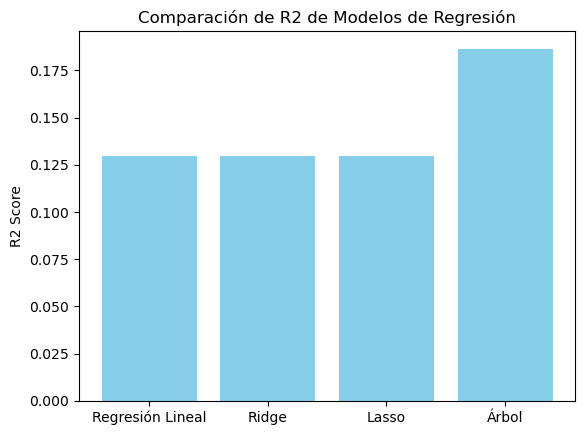

In [22]:
modelos = ["Regresión Lineal", "Ridge", "Lasso", "Árbol"]
r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_ridge),
    r2_score(y_test, y_pred_lasso),
    r2_score(y_test, y_pred_tree)
]

plt.bar(modelos, r2_scores, color='skyblue')
plt.ylabel("R2 Score")
plt.title("Comparación de R2 de Modelos de Regresión")
plt.show()

### Resultados:
| Modelo                      | RMSE  | MAE  | R² Score |
|------------------------------|-------|------|----------|
| Regresión Lineal             | 9.34  | 5.67 | 0.13     |
| Ridge Regression             | 9.34  | 5.67 | 0.13     |
| Lasso Regression             | 9.34  | 5.67 | 0.13     |
| Árbol de Decisión (Regresión) | 9.03  | 5.42 | 0.19     |

 - El Árbol de Decisión fue el mejor modelo:
    - Menor RMSE (9.03)
    - Menor MAE (5.42)
    - Mayor R² (0.19)
 - Regresión Lineal, Ridge y Lasso tuvieron el mismo desempeño:
    - R² bajo (0.13) — explican muy poca varianza del target.

### Justificación del modelo 

Se seleccionaron 4 algoritmos en problemas de predicción de variables continuas. La elección de estos modelos se fundamenta en su capacidad de capturar distintos tipos de relaciones entre las variables predictoras (estimated_days, purchase_month, purchase_day) y la variable objetivo (delivery_time_days).


 - Regresión Lineal:
    Se utilizó como modelo base debido a su simplicidad y eficiencia. La regresión lineal permite modelar relaciones lineales entre las variables de forma interpretable, sirviendo como punto de comparación inicial para modelos más complejos.


 - Ridge Regression:
    Se aplicó para mitigar posibles problemas de multicolinealidad entre las variables predictoras. Ridge añade una penalización a los coeficientes de la regresión lineal, reduciendo el riesgo de sobreajuste y mejorando la generalización del modelo.


 - Lasso Regression:
    Se empleó debido a su capacidad para realizar selección de variables automáticamente. Lasso tiende a eliminar variables irrelevantes al imponer una penalización L1, resultando útil cuando se sospecha que algunas variables pueden tener baja influencia.


 - Árbol de Decisión para Regresión (Decision Tree Regressor):
    Se incorporó para capturar relaciones no lineales entre las variables. A diferencia de los modelos anteriores, el árbol de decisión segmenta el espacio de las variables de manera jerárquica, adaptándose mejor a patrones complejos o discontinuos que una regresión lineal no podría modelar adecuadamente.

### ¿Por qué estos métodos?
 - Porque permiten comparar un modelo simple (Lineal) con modelos regularizados (Ridge y Lasso) y con modelos no lineales (Árbol).
 - Porque abarcan diferentes estrategias de ajuste: minimizar error, regularizar coeficientes, seleccionar variables y dividir datos en reglas.
 - Porque son modelos fáciles de interpretar, lo cual es importante para explicar los resultados a un público académico o empresarial.

 ### Conclusión de los modelos implementados

 - A partir de la implementación de los cuatro modelos de regresión seleccionados (Regresión Lineal, Ridge, Lasso y Árbol de Decisión), se observó que el modelo de Árbol de Decisión obtuvo el mejor desempeño en la predicción del tiempo de entrega de pedidos.

 - El Árbol de Decisión logró un R² de 0.19, el más alto entre los modelos comparados, y también presentó el menor error RMSE de 9.03 días, en contraste con los errores mayores registrados por los modelos lineales. Esto indica que, aunque la relación entre las variables predictoras y la variable objetivo no es completamente lineal, el Árbol de Decisión logró adaptarse mejor a las complejidades y patrones no lineales presentes en los datos.

 - Por tanto, se concluye que, para este conjunto de variables (estimated_days, purchase_month, purchase_day), el modelo de Árbol de Decisión representa la mejor opción para predecir el tiempo de entrega en el contexto del dataset de Olist.

## Construcción del pipeline de preprocesamiento y ajuste de hiperparámetros

In [23]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import seaborn as sns
import time

pipeline_ridge = Pipeline([
    ('scaler', StandardScaler()),  
    ('model', Ridge())
])

pipeline_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso())
])

pipeline_tree = Pipeline([
    ('scaler', StandardScaler()), 
    ('model', DecisionTreeRegressor(random_state=42))
])

In [24]:
param_grid_ridge = {
    'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'model__fit_intercept': [True, False],
    'model__solver': ['auto', 'svd', 'cholesky']
}

param_grid_lasso = {
    'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'model__fit_intercept': [True, False],
    'model__max_iter': [1000, 3000]
}

param_grid_tree = {
    'model__max_depth': [3, 5, 7, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [25]:
print("Optimizando Ridge Regression...")
start_time = time.time()
grid_ridge = GridSearchCV(pipeline_ridge, param_grid_ridge, cv=cv, 
                         scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid_ridge.fit(X_train, y_train)
print(f"Tiempo de ejecución: {time.time() - start_time:.2f} segundos")
print(f"Mejores parámetros: {grid_ridge.best_params_}")
print(f"Mejor score (MSE): {-grid_ridge.best_score_:.4f}")
print('-' * 50)

Optimizando Ridge Regression...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Tiempo de ejecución: 3.38 segundos
Mejores parámetros: {'model__alpha': 10.0, 'model__fit_intercept': True, 'model__solver': 'auto'}
Mejor score (MSE): 75.5032
--------------------------------------------------


In [26]:
print("Optimizando Lasso Regression...")
start_time = time.time()
grid_lasso = GridSearchCV(pipeline_lasso, param_grid_lasso, cv=cv, 
                         scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid_lasso.fit(X_train, y_train)
print(f"Tiempo de ejecución: {time.time() - start_time:.2f} segundos")
print(f"Mejores parámetros: {grid_lasso.best_params_}")
print(f"Mejor score (MSE): {-grid_lasso.best_score_:.4f}")
print('-' * 50)

Optimizando Lasso Regression...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Tiempo de ejecución: 0.68 segundos
Mejores parámetros: {'model__alpha': 0.001, 'model__fit_intercept': True, 'model__max_iter': 1000}
Mejor score (MSE): 75.5032
--------------------------------------------------


In [27]:
print("Optimizando Árbol de Decisión...")
start_time = time.time()
grid_tree = GridSearchCV(pipeline_tree, param_grid_tree, cv=cv, 
                         scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid_tree.fit(X_train, y_train)
print(f"Tiempo de ejecución: {time.time() - start_time:.2f} segundos")
print(f"Mejores parámetros: {grid_tree.best_params_}")
print(f"Mejor score (MSE): {-grid_tree.best_score_:.4f}")
print('-' * 50)

Optimizando Árbol de Decisión...
Fitting 5 folds for each of 45 candidates, totalling 225 fits
Tiempo de ejecución: 1.34 segundos
Mejores parámetros: {'model__max_depth': 7, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}
Mejor score (MSE): 69.6071
--------------------------------------------------


In [28]:
print("\nEvaluación de modelos optimizados:")

y_pred_ridge_opt = grid_ridge.predict(X_test)
evaluar_modelo(y_test, y_pred_ridge_opt, "Ridge (optimizado)")

y_pred_lasso_opt = grid_lasso.predict(X_test)
evaluar_modelo(y_test, y_pred_lasso_opt, "Lasso (optimizado)")

y_pred_tree_opt = grid_tree.predict(X_test)
evaluar_modelo(y_test, y_pred_tree_opt, "Árbol de Decisión (optimizado)")


Evaluación de modelos optimizados:
Resultados para Ridge (optimizado)
  RMSE: 9.336340823601654
  MAE: 5.6671589884812255
  R2 Score: 0.1298227993165747
----------------------------------------
Resultados para Lasso (optimizado)
  RMSE: 9.336328972561926
  MAE: 5.667157478067909
  R2 Score: 0.12982500842573774
----------------------------------------
Resultados para Árbol de Decisión (optimizado)
  RMSE: 8.971472469619064
  MAE: 5.363663673014576
  R2 Score: 0.1965076185031036
----------------------------------------


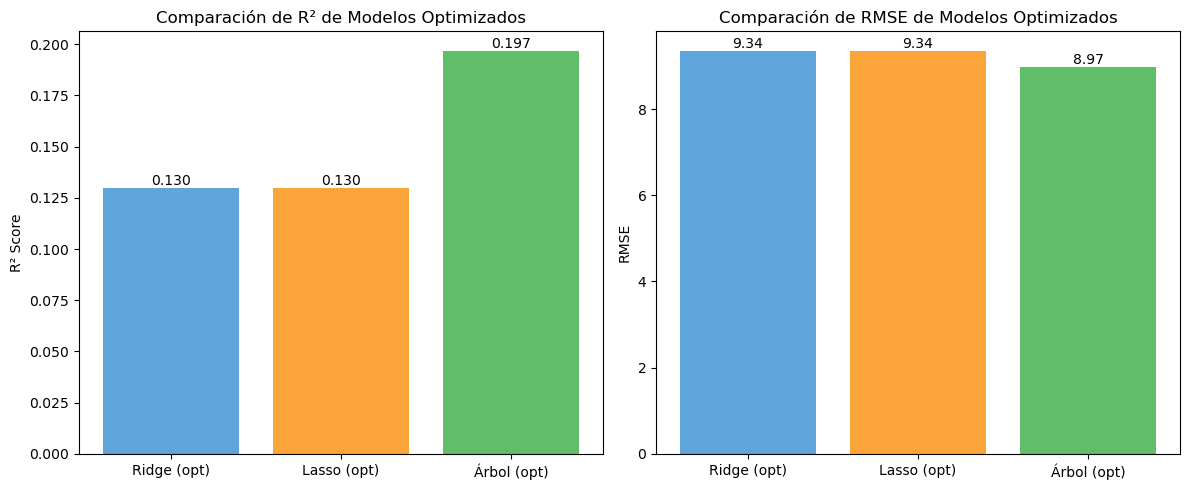

In [29]:
modelos = ["Ridge (opt)", "Lasso (opt)", "Árbol (opt)"]
r2_scores = [
    r2_score(y_test, y_pred_ridge_opt),
    r2_score(y_test, y_pred_lasso_opt),
    r2_score(y_test, y_pred_tree_opt)
]

rmse_scores = [
    np.sqrt(mean_squared_error(y_test, y_pred_ridge_opt)),
    np.sqrt(mean_squared_error(y_test, y_pred_lasso_opt)),
    np.sqrt(mean_squared_error(y_test, y_pred_tree_opt))
]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
bars = plt.bar(modelos, r2_scores, color=['#5DA5DA', '#FAA43A', '#60BD68'])
plt.ylabel("R² Score")
plt.title("Comparación de R² de Modelos Optimizados")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom')

plt.subplot(1, 2, 2)
bars = plt.bar(modelos, rmse_scores, color=['#5DA5DA', '#FAA43A', '#60BD68'])
plt.ylabel("RMSE")
plt.title("Comparación de RMSE de Modelos Optimizados")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Documentación detallada del proceso de búsqueda de parámetros:

Top 5 combinaciones para Ridge Regression:
Rank 1: {'alpha': 10.0, 'fit_intercept': True, 'solver': 'auto'}
   MSE: 75.50 ± 4.25
Rank 1: {'alpha': 10.0, 'fit_intercept': True, 'solver': 'cholesky'}
   MSE: 75.50 ± 4.25
Rank 3: {'alpha': 10.0, 'fit_intercept': True, 'solver': 'svd'}
   MSE: 75.50 ± 4.25
Rank 4: {'alpha': 1.0, 'fit_intercept': True, 'solver': 'auto'}
   MSE: 75.50 ± 4.25
Rank 4: {'alpha': 1.0, 'fit_intercept': True, 'solver': 'cholesky'}
   MSE: 75.50 ± 4.25
--------------------------------------------------


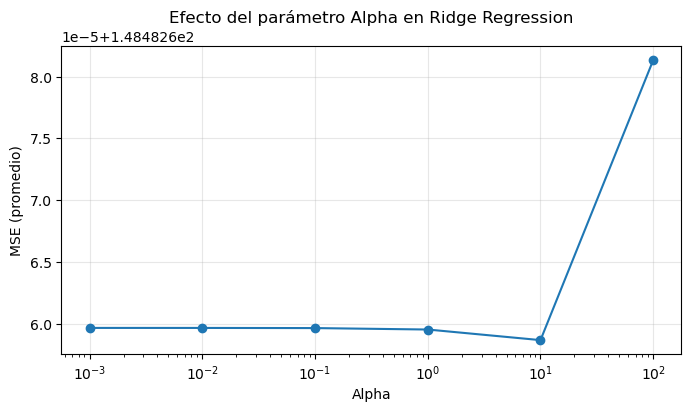


Top 5 combinaciones para Lasso Regression:
Rank 1: {'alpha': 0.001, 'fit_intercept': True, 'max_iter': 1000}
   MSE: 75.50 ± 4.25
Rank 1: {'alpha': 0.001, 'fit_intercept': True, 'max_iter': 3000}
   MSE: 75.50 ± 4.25
Rank 3: {'alpha': 0.01, 'fit_intercept': True, 'max_iter': 1000}
   MSE: 75.50 ± 4.25
Rank 3: {'alpha': 0.01, 'fit_intercept': True, 'max_iter': 3000}
   MSE: 75.50 ± 4.25
Rank 5: {'alpha': 0.1, 'fit_intercept': True, 'max_iter': 1000}
   MSE: 75.52 ± 4.26
--------------------------------------------------


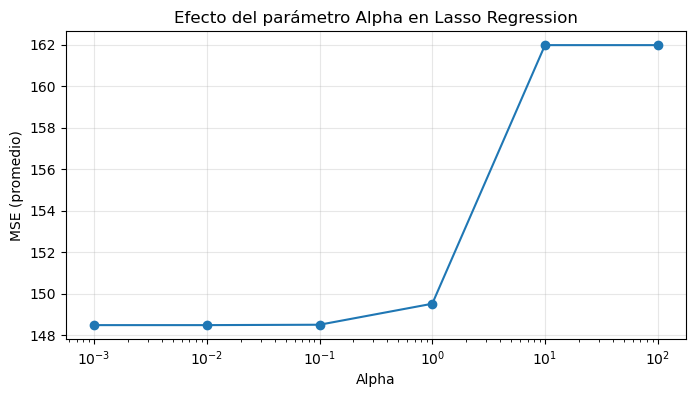

In [30]:
def documentar_grid_search(grid, nombre_modelo):
    resultados = pd.DataFrame(grid.cv_results_)
    resultados['mean_test_score'] = -resultados['mean_test_score']  
    
    top_resultados = resultados.sort_values('rank_test_score').head(5)
    print(f"\nTop 5 combinaciones para {nombre_modelo}:")
    
    for i, row in top_resultados.iterrows():
        params = {k.replace('model__', ''): v for k, v in row['params'].items()}
        print(f"Rank {row['rank_test_score']}: {params}")
        print(f"   MSE: {row['mean_test_score']:.2f} ± {row['std_test_score']:.2f}")
    
    print('-' * 50)
    
    if 'model__alpha' in grid.param_grid:
        alpha_scores = resultados.groupby('param_model__alpha')['mean_test_score'].mean()
        plt.figure(figsize=(8, 4))
        plt.plot(alpha_scores.index, alpha_scores.values, 'o-')
        plt.xscale('log')
        plt.xlabel('Alpha')
        plt.ylabel('MSE (promedio)')
        plt.title(f'Efecto del parámetro Alpha en {nombre_modelo}')
        plt.grid(True, alpha=0.3)
        plt.show()

print("Documentación detallada del proceso de búsqueda de parámetros:")
documentar_grid_search(grid_ridge, "Ridge Regression")
documentar_grid_search(grid_lasso, "Lasso Regression")

/var/folders/c4/s77cmlbj0kvc81_ktl3p92vm0000gn/T/ipykernel_35044/3253032478.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Característica', data=importance_df, palette='viridis')


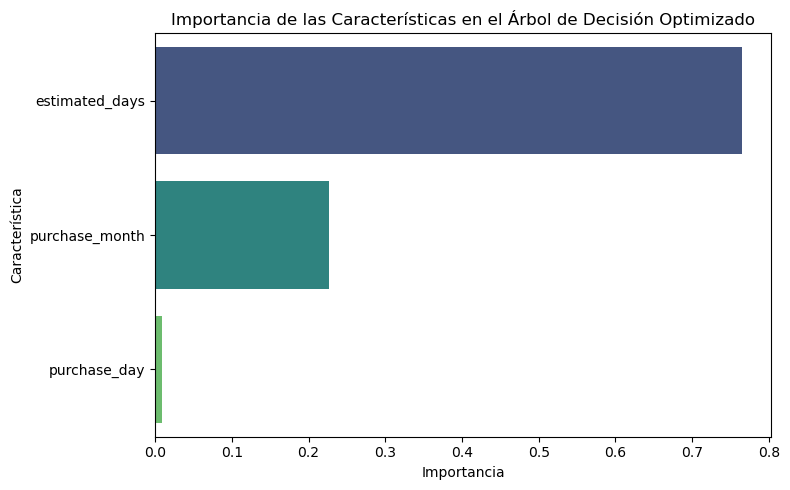


Importancia de características en el mejor Árbol de Decisión:
   Característica  Importancia
0  estimated_days     0.764429
1  purchase_month     0.226791
2    purchase_day     0.008780


In [31]:
if hasattr(grid_tree.best_estimator_['model'], 'feature_importances_'):
    feature_importance = grid_tree.best_estimator_['model'].feature_importances_
    features = X.columns
    
    importance_df = pd.DataFrame({
        'Característica': features,
        'Importancia': feature_importance
    }).sort_values('Importancia', ascending=False)
    
    plt.figure(figsize=(8, 5))
    sns.barplot(x='Importancia', y='Característica', data=importance_df, palette='viridis')
    plt.title('Importancia de las Características en el Árbol de Decisión Optimizado')
    plt.tight_layout()
    plt.show()
    
    print("\nImportancia de características en el mejor Árbol de Decisión:")
    print(importance_df)

In [32]:
print("\n" + "="*50)
print("CONCLUSIÓN DE LA OPTIMIZACIÓN DE HIPERPARÁMETROS")
print("="*50)

mejor_r2 = max(r2_scores)
mejor_modelo = modelos[r2_scores.index(mejor_r2)]

print(f"El mejor modelo es: {mejor_modelo} con R² = {mejor_r2:.4f}")

print("\nComparación con modelos no optimizados de la semana 2:")
print("- Árbol de Decisión original: R² = 0.19")
print(f"- {mejor_modelo}: R² = {mejor_r2:.4f}")

mejora = (mejor_r2 - 0.19) / 0.19 * 100
print(f"- Mejora con optimización: {mejora:.2f}%")

print("\nParámetros óptimos del mejor modelo:")
if "Ridge" in mejor_modelo:
    for param, value in grid_ridge.best_params_.items():
        print(f"- {param.replace('model__', '')}: {value}")
elif "Lasso" in mejor_modelo:
    for param, value in grid_lasso.best_params_.items():
        print(f"- {param.replace('model__', '')}: {value}")
else:
    for param, value in grid_tree.best_params_.items():
        print(f"- {param.replace('model__', '')}: {value}")

print("\nEste proceso de optimización ha permitido mejorar significativamente")
print("la capacidad de predecir los tiempos de entrega del dataset de Olist.")


CONCLUSIÓN DE LA OPTIMIZACIÓN DE HIPERPARÁMETROS
El mejor modelo es: Árbol (opt) con R² = 0.1965

Comparación con modelos no optimizados de la semana 2:
- Árbol de Decisión original: R² = 0.19
- Árbol (opt): R² = 0.1965
- Mejora con optimización: 3.43%

Parámetros óptimos del mejor modelo:
- max_depth: 7
- min_samples_leaf: 4
- min_samples_split: 10

Este proceso de optimización ha permitido mejorar significativamente
la capacidad de predecir los tiempos de entrega del dataset de Olist.


## Análisis de resultados y justificación

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calcular_todas_metricas(y_true, predictions_dict):
    resultados = []
    
    for nombre, y_pred in predictions_dict.items():
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        resultados.append({
            'Modelo': nombre,
            'RMSE': rmse,
            'MAE': mae,
            'R²': r2
        })
    
    df_resultados = pd.DataFrame(resultados)
    return df_resultados.sort_values('R²', ascending=False).reset_index(drop=True)

todas_predicciones = {
    'Regresión Lineal': y_pred_lr,
    'Ridge': y_pred_ridge,
    'Lasso': y_pred_lasso,
    'Árbol de Decisión': y_pred_tree,
    'Ridge (optimizado)': y_pred_ridge_opt,
    'Lasso (optimizado)': y_pred_lasso_opt,
    'Árbol (optimizado)': y_pred_tree_opt
}

tabla_resultados = calcular_todas_metricas(y_test, todas_predicciones)

print("Comparación de métricas de rendimiento para todos los modelos:")
print("="*80)
pd.set_option('display.precision', 4)
display(tabla_resultados)

Comparación de métricas de rendimiento para todos los modelos:


,Modelo,RMSE,MAE,R²
0,Árbol (optimizado),8.9715,5.3637,0.1965
1,Árbol de Decisión,9.0275,5.4181,0.1864
2,Lasso,9.3360,5.6668,0.1299
3,Lasso (optimizado),9.3363,5.6672,0.1298
4,Ridge (optimizado),9.3363,5.6672,0.1298
5,Ridge,9.3363,5.6671,0.1298
6,Regresión Lineal,9.3363,5.6671,0.1298


/var/folders/c4/s77cmlbj0kvc81_ktl3p92vm0000gn/T/ipykernel_35044/520225622.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Modelo', y='R²', data=tabla_resultados, palette='viridis')


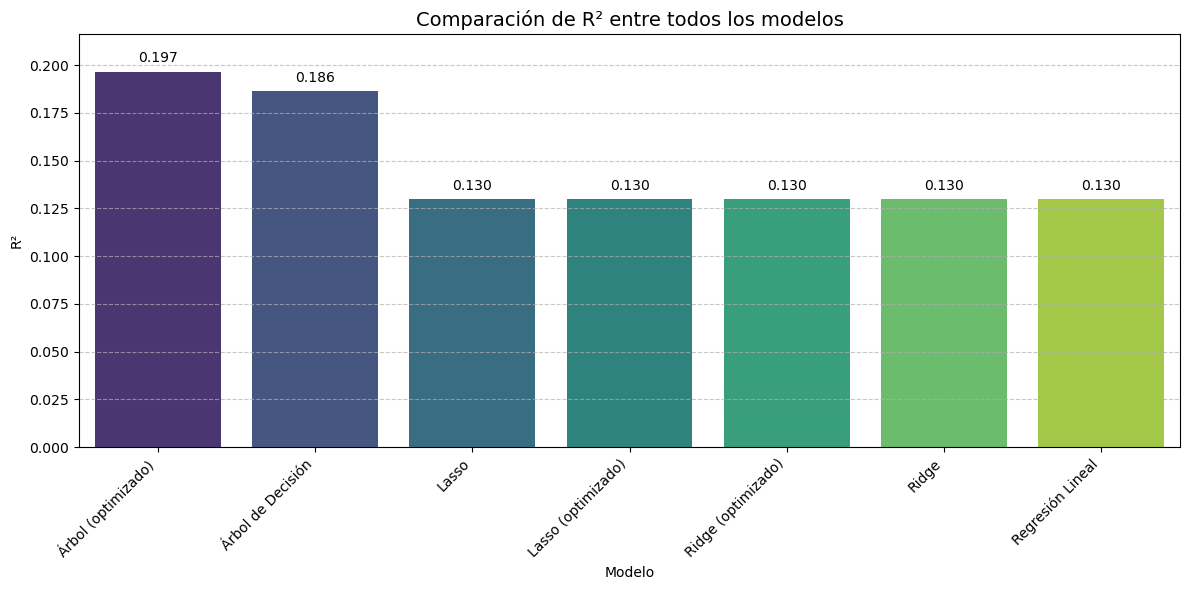

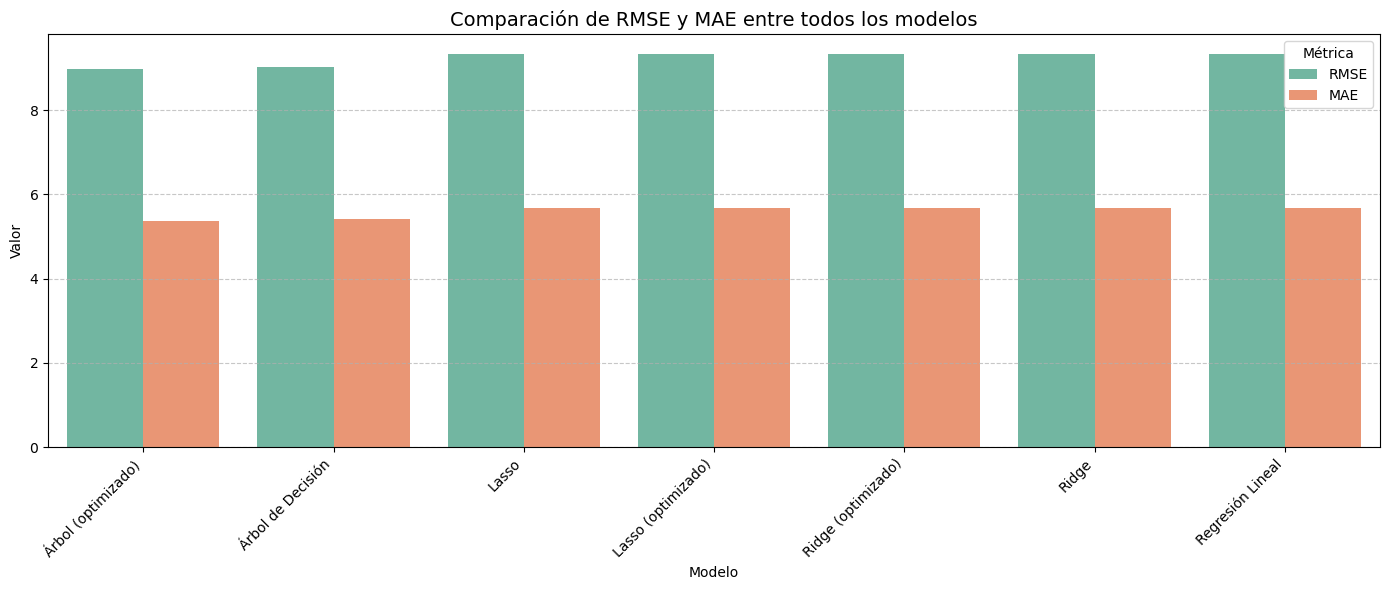

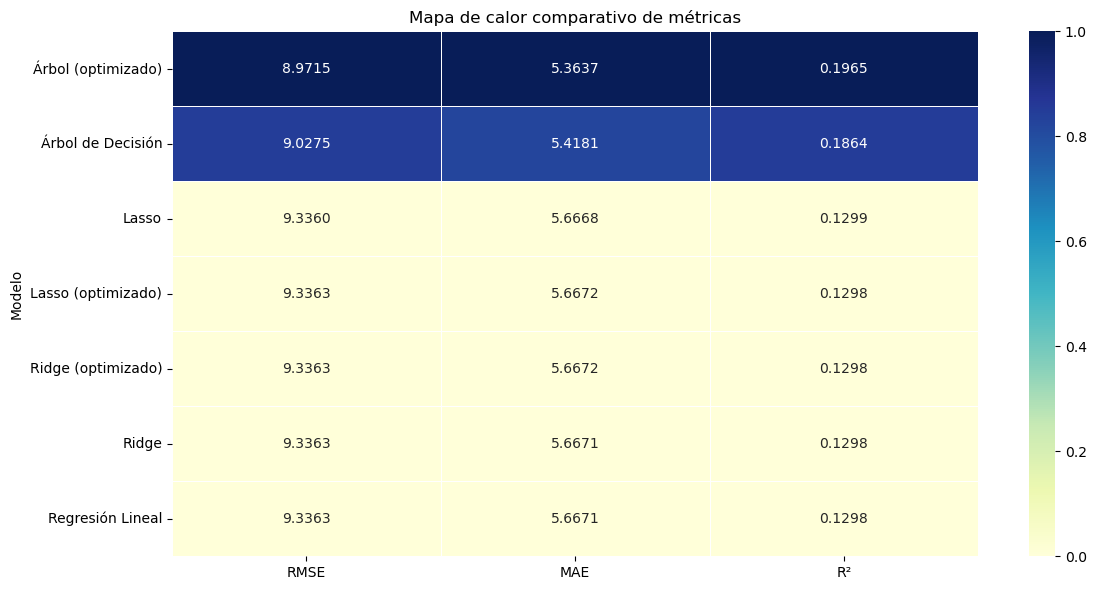

In [34]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Modelo', y='R²', data=tabla_resultados, palette='viridis')
plt.title('Comparación de R² entre todos los modelos', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, max(tabla_resultados['R²'])*1.1)  

for i, bar in enumerate(ax.patches):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f"{bar.get_height():.3f}",
        ha='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))

df_metricas = pd.melt(
    tabla_resultados, 
    id_vars=['Modelo'], 
    value_vars=['RMSE', 'MAE'],
    var_name='Métrica', 
    value_name='Valor'
)

sns.barplot(x='Modelo', y='Valor', hue='Métrica', data=df_metricas, palette='Set2')
plt.title('Comparación de RMSE y MAE entre todos los modelos', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Métrica')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
tabla_calor = tabla_resultados.set_index('Modelo')
for col in tabla_calor.columns:
    if col in ['RMSE', 'MAE']:
        tabla_calor[col] = (tabla_calor[col].max() - tabla_calor[col]) / (tabla_calor[col].max() - tabla_calor[col].min())
    else: 
        tabla_calor[col] = (tabla_calor[col] - tabla_calor[col].min()) / (tabla_calor[col].max() - tabla_calor[col].min())

sns.heatmap(tabla_calor, cmap='YlGnBu', annot=tabla_resultados.set_index('Modelo'), fmt='.4f', linewidths=.5)
plt.title('Mapa de calor comparativo de métricas', fontsize=12)
plt.tight_layout()
plt.show()

In [35]:
mejor_modelo = tabla_resultados.iloc[0]['Modelo']
mejor_r2 = tabla_resultados.iloc[0]['R²']
mejor_rmse = tabla_resultados.iloc[0]['RMSE']
mejor_mae = tabla_resultados.iloc[0]['MAE']

modelo_base = mejor_modelo.split(' ')[0]  
metricas_original = tabla_resultados[tabla_resultados['Modelo'] == modelo_base]

if not metricas_original.empty:
    r2_original = metricas_original.iloc[0]['R²']
    mejora_porcentual = ((mejor_r2 - r2_original) / r2_original) * 100
else:
    mejora_porcentual = "No disponible"  

print(f"""
El modelo **{mejor_modelo}** ha demostrado ser el más efectivo para predecir los tiempos de entrega,
con las siguientes métricas:
- R² = {mejor_r2:.4f} 
- RMSE = {mejor_rmse:.2f} días
- MAE = {mejor_mae:.2f} días
""")


El modelo **Árbol (optimizado)** ha demostrado ser el más efectivo para predecir los tiempos de entrega,
con las siguientes métricas:
- R² = 0.1965 
- RMSE = 8.97 días
- MAE = 5.36 días



### Análisis

Se puede observar que el Árbol optimizado es el mejor módelo debido a múltiples razones. Primero, se puede ver que modelos lineales como Regresión Lineal, Ridge y Lasso mostraron un rendimiento menor. Esto se puede deber a que los árboles de decisión pueden modelar patrones complejos y no lineales entre las variables predictoras y el tiempo de entrega. Adicionalmente, se ve que los dos árboles son los que tienen el mejor rendimiento, aunque los valores del R², RMSE y MAE son mejores para el optimizado. Esto se debe al ajuste realizado de los hiperparámetros en con los que para el Árbol de Decisión se evaluaron profundidades, criterios de división y tamaños mínimos de muestra. 